# Weak Mixed k-Metric Dimensions
1. Določanje $\kappa ''(G)$ in $wmdim_{k}(G)$ za polne grafe s pomočjo CLP modela.

In [8]:
# nalozimo potrebne knjiznice

from sage.all import *
from sage.graphs.graph_generators import graphs
from sage.graphs.graph import Graph
import networkx as nx
import pulp 
from pulp import LpProblem, LpVariable, LpMinimize, lpSum
from sage.numerical.mip import MixedIntegerLinearProgram


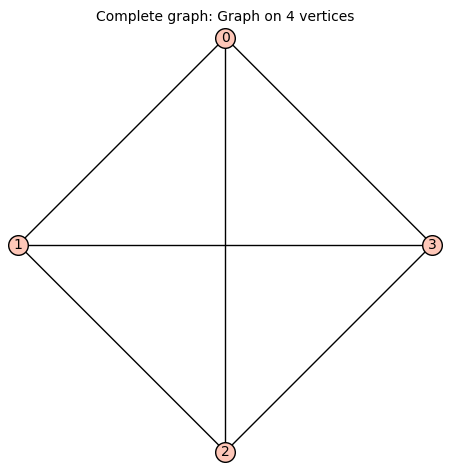

In [27]:

# definiramo polne grafe
def complete_graph_k(n):
    return graphs.CompleteGraph(n)

complete_graph_k(4)


In [30]:


def complete_graph_k(n):
    """Generate a complete graph K_n using NetworkX."""
    return nx.complete_graph(n)

def compute_wmdim_k(G, k):
    vertices = list(G.nodes())
    edges = list(G.edges())
    n = len(vertices)
    
    prob = LpProblem("Weak_Mixed_Metric_Dimension", LpMinimize)
    
    S = LpVariable.dicts("S", vertices, cat="Binary")
    
    prob += lpSum(S[v] for v in vertices)
  
    for a in vertices:
        for b in vertices:
            if a != b:
                prob += lpSum(S[s] * abs(nx.shortest_path_length(G, s, a) - nx.shortest_path_length(G, s, b)) for s in vertices) >= k
    
    prob.solve()
    
    S_optimal = [v for v in vertices if S[v].varValue > 0.5]
    
    return len(S_optimal), S_optimal



In [ ]:
# ne dela!!!

def complete_graph_k(n):
    return Graph(complete=True, order=n)

def compute_wmdim_k(G, k):
    vertices = list(G.vertices())
    n = len(vertices)
    
    prob = MixedIntegerLinearProgram(maximization=False)
    S = prob.new_variable(binary=True)
    
    prob.set_objective(sum(S[v] for v in vertices))
    
    for a in vertices:
        for b in vertices:
            if a != b:
                prob.add_constraint(
                    sum(S[s] * abs(G.distance(s, a) - G.distance(s, b)) for s in vertices) >= k
                )
    
    prob.solve()
    
    S_optimal = [v for v in vertices if prob.get_values(S[v]) > 0.5]
    
    return len(S_optimal), S_optimal




In [31]:

G = complete_graph_k(4)
k = 1  
wmdim_k, S_optimal = compute_wmdim_k(G, k)
print(f"Selected vertices for k={k}: wmdim_k = {wmdim_k}, S = {S_optimal}")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/lanmedle/Library/SageMath-10-5/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/_r/s4w79bj50zj392_7sdzcjzwc0000gn/T/807e9b6ef472464ca80a95640e783014-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/_r/s4w79bj50zj392_7sdzcjzwc0000gn/T/807e9b6ef472464ca80a95640e783014-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 17 COLUMNS
At line 54 RHS
At line 67 BOUNDS
At line 72 ENDATA
Problem MODEL has 12 rows, 4 columns and 24 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 2 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 3 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 3 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 2 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 1 tightened 

In [25]:

for n in range(3, 7):  
    G = complete_graph_k(n)
    k_values = range(1, n)  
    print(f"Complete Graph K_{n}:")
    for k in k_values:
        wmdim_k, S_optimal = compute_wmdim_k(G, k)
        print(f"Selected vetrices for k={k}: wmdim_k = {wmdim_k}, S = {S_optimal}")

Complete Graph K_3:
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/lanmedle/Library/SageMath-10-5/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/_r/s4w79bj50zj392_7sdzcjzwc0000gn/T/46d9cef52d834702a97febc7ab75709f-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/_r/s4w79bj50zj392_7sdzcjzwc0000gn/T/46d9cef52d834702a97febc7ab75709f-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 11 COLUMNS
At line 33 RHS
At line 40 BOUNDS
At line 44 ENDATA
Problem MODEL has 6 rows, 3 columns and 12 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 1.5 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 1 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 1 strengthened rows, 0 substitutions
Cgl0004I processed model has 1 rows, 2 columns (2 integer (1 of which binary)) and 2